# Import Libraries

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
import pickle
import re
import warnings
from urllib.parse import unquote
import json
import os


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from keras.layers import (
    Conv1D,
    Dense,
    Dropout,
    GlobalMaxPooling1D,
    Input,
    Embedding,
    SpatialDropout1D,
    Concatenate,
)
from keras.models import Model
from keras import regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import shuffle
from wordcloud import WordCloud

color = sns.color_palette()
pd.set_option("display.max_colwidth", 200)
warnings.filterwarnings("ignore")

n_cores = os.cpu_count() or 4
tf.config.threading.set_intra_op_parallelism_threads(min(12, n_cores))
tf.config.threading.set_inter_op_parallelism_threads(min(12, n_cores))

%matplotlib inline

# Data Exploration

In [5]:
# df = pd.read_csv("/content/drive/MyDrive/dataset_crawl_070526.csv")
df = pd.read_csv("./dataset/dataset_crawl_070526.csv")

In [6]:
df.shape

(201465, 5)

In [7]:
df.head()

,Webpage_id,Domain,Url,Tag,Crawled_at
0,1,abcnews.go.com,https://abcnews.go.com/live,non-gambling,2026-04-27 15:16:52
1,2,abcnews.go.com,https://abcnews.go.com/international,non-gambling,2026-04-27 15:16:54
2,3,abcnews.go.com,https://abcnews.go.com/lifestyle,non-gambling,2026-04-27 15:16:56
3,4,abcnews.go.com,https://abcnews.go.com/us,non-gambling,2026-04-27 15:16:58
4,5,abcnews.go.com,https://abcnews.go.com/business,non-gambling,2026-04-27 15:17:04


In [8]:
df['Tag'].unique()

<StringArray>
['non-gambling', 'gambling']
Length: 2, dtype: str

In [9]:
df[df['Tag'] == 'non-gambling'].head()

,Webpage_id,Domain,Url,Tag,Crawled_at
0,1,abcnews.go.com,https://abcnews.go.com/live,non-gambling,2026-04-27 15:16:52
1,2,abcnews.go.com,https://abcnews.go.com/international,non-gambling,2026-04-27 15:16:54
2,3,abcnews.go.com,https://abcnews.go.com/lifestyle,non-gambling,2026-04-27 15:16:56
3,4,abcnews.go.com,https://abcnews.go.com/us,non-gambling,2026-04-27 15:16:58
4,5,abcnews.go.com,https://abcnews.go.com/business,non-gambling,2026-04-27 15:17:04


In [10]:
df[df['Tag'] == 'gambling'].head()

,Webpage_id,Domain,Url,Tag,Crawled_at
101313,101314,03oncuuy7j.slotmantapviral.com,https://03oncuuy7j.slotmantapviral.com/mobile/home,gambling,2026-05-06 10:01:42
101314,101315,03oncuuy7j.slotmantapviral.com,https://03oncuuy7j.slotmantapviral.com/desktop/home,gambling,2026-05-06 10:01:44
101315,101316,03oncuuy7j.slotmantapviral.com,https://03oncuuy7j.slotmantapviral.com/desktop/hot-games,gambling,2026-05-06 10:01:46
101316,101317,03oncuuy7j.slotmantapviral.com,https://03oncuuy7j.slotmantapviral.com/desktop/slots/pragmatic,gambling,2026-05-06 10:01:51
101317,101318,03oncuuy7j.slotmantapviral.com,https://03oncuuy7j.slotmantapviral.com/desktop/slots/jili,gambling,2026-05-06 10:01:53


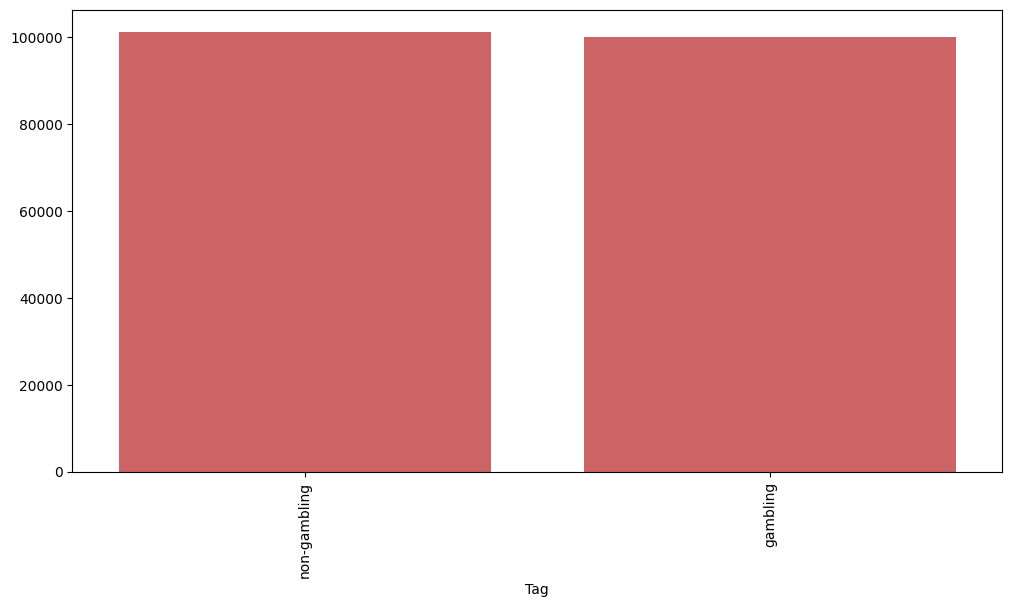

In [11]:
cnt_tag = df['Tag'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=cnt_tag.index, y=cnt_tag.values, alpha=0.8, color=color[3])
plt.xticks(rotation='vertical')
plt.show()

In [12]:
all_words = ' '.join([text for text in df['Url']])
wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(all_words)

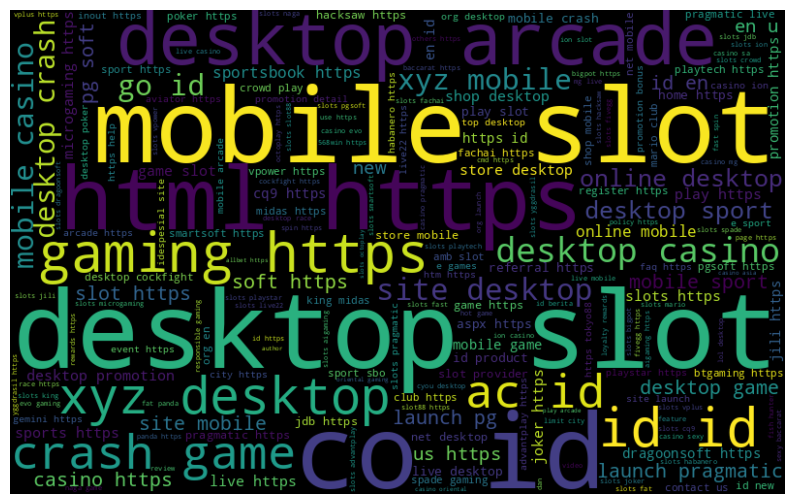

In [13]:
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

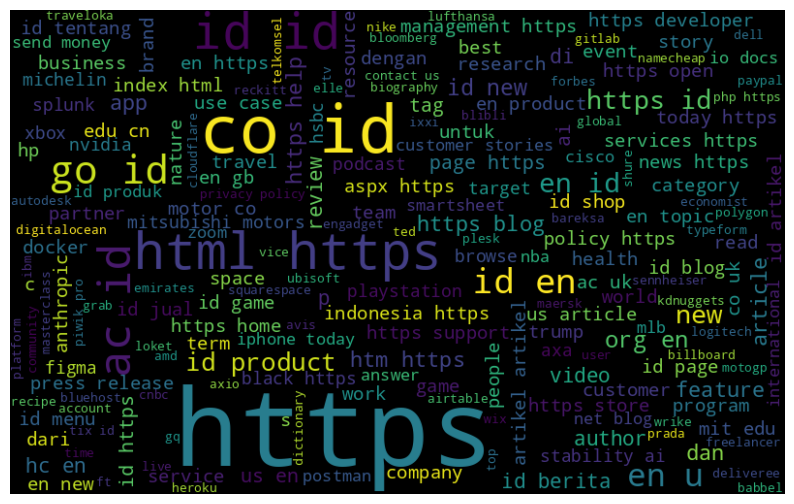

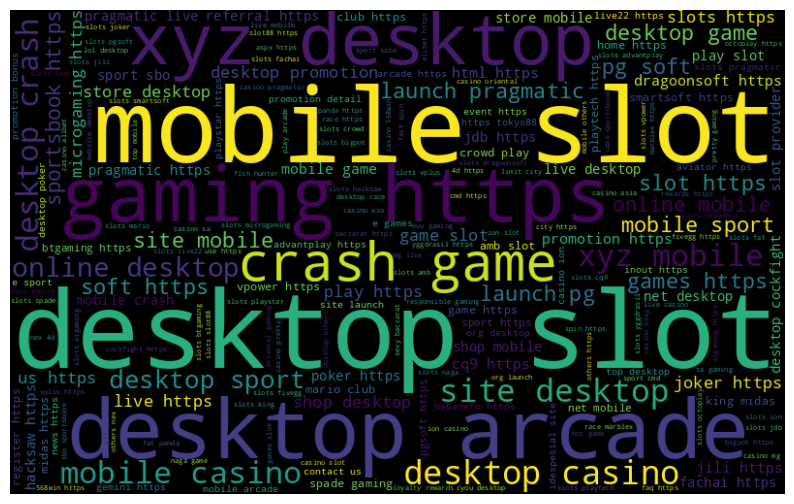

In [14]:
for tag in ("non-gambling", "gambling"):
    words = " ".join(t for t in df[df["Tag"] == tag]["Url"])
    wc = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(
        words
    )
    plt.figure(figsize=(10, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

# Data Preprocessing & Cleaning

In [15]:
def clean_url(url_string):
    url = unquote(url_string).lower()
    url = re.sub(r"https?:\/\/", "", url)
    url = re.sub(r"[-_/]", " ", url)
    url = re.sub(r"[^a-zA-Z0-9\s]", " ", url)
    url = re.sub(r"(\d)([a-z])", r"\1 \2", url)
    url = re.sub(r"([a-z])(\d)", r"\1 \2", url)
    url = re.sub(r"\s+", " ", url).strip()
    return url

In [16]:
df['cleaned_url'] = df['Url'].apply(clean_url)
df['cleaned_url'].head()

0             abcnews go com live
1    abcnews go com international
2        abcnews go com lifestyle
3               abcnews go com us
4         abcnews go com business
Name: cleaned_url, dtype: str

In [17]:
def extract_url_meta(raw_url):
    url = str(raw_url)
    url_len = len(url)
    digit_ratio = sum(c.isdigit() for c in url) / max(len(url), 1)
    special_char_ratio = sum(not c.isalnum() for c in url) / max(len(url), 1)
    path = re.sub(r'https?://[^/]+', '', url)
    path_depth = len([p for p in path.split('/') if p])
    netloc = re.search(r'https?://([^/]+)', url)
    domain = netloc.group(1) if netloc else url.split('/')[0]
    num_subdomains = max(0, domain.count('.') - 1)
    has_ip = 1 if re.match(r'\d+\.\d+\.\d+\.\d+', domain) else 0
    return [url_len, digit_ratio, special_char_ratio, path_depth, num_subdomains, has_ip]

In [18]:
meta_cols = ['url_len', 'digit_ratio', 'special_char_ratio', 'path_depth', 'num_subdomains', 'has_ip']
df[meta_cols] = df['Url'].apply(lambda x: pd.Series(extract_url_meta(x)))

In [19]:
TAG_DICT = {"non-gambling":0, "gambling": 1}
df['target'] = df.Tag.map(TAG_DICT)
display(df["target"].head(), df["target"].tail())

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

201460    1
201461    1
201462    1
201463    1
201464    1
Name: target, dtype: int64

In [20]:
# (URL dari domain yg sama tidak boleh terpisah train/val)
df["domain_group"] = df["Domain"].values
df["domain_group"].head()
df["domain_group"].tail()

201460    zipzapslotvip.best
201461    zipzapslotvip.best
201462    zipzapslotvip.best
201463    zipzapslotvip.best
201464    zipzapslotvip.best
Name: domain_group, dtype: str

In [21]:
# StratifiedGroupKFold menjaga proporsi kelas tiap fold
# karena domain gambling (1145) >> domain non-gambling (562),
# GroupKFold biasa bisa bikin fold dg proporsi kelas timpang
X_text = df["cleaned_url"].values
X_meta = df[meta_cols].values.astype(np.float32)
y = df["target"].values
groups = df["domain_group"].values

gkf = StratifiedGroupKFold(n_splits=5)
cvlist = list(gkf.split(df, y, groups=groups))

# Feature Engineering

#### Bag of Words

In [22]:
bow_pipe = Pipeline(
    [
        ("vec", CountVectorizer(ngram_range=(1, 3), min_df=400)),
        ("clf", MultinomialNB(alpha=1.0)),
    ]
)

In [23]:
bow_scores = cross_val_score(bow_pipe, X_text, y, cv=cvlist, scoring="f1", n_jobs=-1)


#### Character N-Grams

In [24]:
char_ngram_pipe = Pipeline([
    (
        "union",
        FeatureUnion([
            (
                "char",
                CountVectorizer(
                    analyzer="char",
                    ngram_range=(1, 5),
                    min_df=500
                ),
            ),
            (
                "word",
                CountVectorizer(
                    analyzer="word",
                    ngram_range=(1, 3),
                    min_df=400
                ),
            ),
        ]),
    ),
    (
        "clf",
        MultinomialNB(alpha=1.0),
    ),
])

In [25]:
char_ngram_scores = cross_val_score(
    char_ngram_pipe, X_text, y, cv=cvlist, scoring="f1", n_jobs=-1
)

#### TFIDF Features

In [26]:
tfidf_pipe = Pipeline([
    (
        "union",
        FeatureUnion([
            (
                "char",
                TfidfVectorizer(
                    analyzer="char",
                    ngram_range=(1, 5),
                    min_df=500
                ),
            ),
            (
                "word",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 3),
                    min_df=400
                ),
            ),
        ]),
    ),
    (
        "clf",
        MultinomialNB(alpha=1.0),
    ),
])

In [27]:
tfidf_scores = cross_val_score(
    tfidf_pipe, X_text, y, cv=cvlist, scoring="f1", n_jobs=-1
)

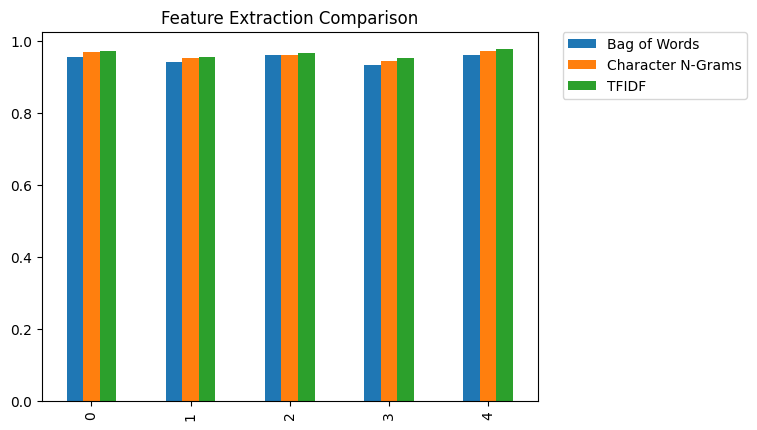

In [28]:
feat_results = pd.DataFrame(
    {
        "Bag of Words": bow_scores,
        "Character N-Grams": char_ngram_scores,
        "TFIDF": tfidf_scores,
    }
)

feat_results.plot(kind="bar")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
plt.title("Feature Extraction Comparison")
plt.show()

In [29]:
feat_summary = pd.DataFrame({
        "Mean F1-Score": feat_results.mean(),
        "Std Deviasi (Kestabilan)": feat_results.std(),
    }).sort_values(
        by=["Mean F1-Score", "Std Deviasi (Kestabilan)"],
        ascending=[False, True],
    )

print("=== Peringkat Feature Extraction ===")
print(feat_summary)
print("-" * 30)
best_feat_name = feat_summary.index[0]
best_feat_score = feat_summary["Mean F1-Score"].iloc[0]
print(f"\nFeature terbaik: {best_feat_name} (F1 = {best_feat_score:.4f})")

=== Peringkat Feature Extraction ===
                   Mean F1-Score  Std Deviasi (Kestabilan)
TFIDF                   0.965169                  0.010698
Character N-Grams       0.960655                  0.011536
Bag of Words            0.950935                  0.012440
------------------------------

Feature terbaik: TFIDF (F1 = 0.9652)


In [30]:
_tfidf_union = FeatureUnion(
    [
        ("char", TfidfVectorizer(analyzer="char", ngram_range=(1, 5), min_df=500)),
        ("word", TfidfVectorizer(analyzer="word", ngram_range=(1, 3), min_df=400)),
    ]
)

# Model Evaluation & Cross Validation

#### Naive Bayes

In [31]:
nb_pipe = Pipeline([("feat", _tfidf_union), ("clf", MultinomialNB(alpha=1.0))])
nb_scores = cross_val_score(nb_pipe, X_text, y, cv=cvlist, scoring="f1", n_jobs=-1)

#### Logistic Regression

In [32]:
lr_pipe = Pipeline(
    [("feat", _tfidf_union), ("clf", LogisticRegression(C=0.1, max_iter=1000))]
)
lr_scores = cross_val_score(lr_pipe, X_text, y, cv=cvlist, scoring="f1", n_jobs=-1)

#### Tree Based Methods

In [ ]:
dt_pipe = Pipeline(
    [
        ("feat", _tfidf_union),
        ("clf", DecisionTreeClassifier(min_samples_leaf=25, min_samples_split=25)),
    ]
)
dt_scores = cross_val_score(dt_pipe, X_text, y, cv=cvlist, scoring="f1", n_jobs=-1)

#### Random Forest

In [ ]:
rf_pipe = Pipeline(
    [
        ("feat", _tfidf_union),
        (
            "clf",
            RandomForestClassifier(
                random_state=0, n_jobs=1, n_estimators=100, max_depth=50
            ),
        ),
    ]
)
rf_scores = cross_val_score(rf_pipe, X_text, y, cv=cvlist, scoring="f1", n_jobs=-1)

In [ ]:
model_results = pd.DataFrame(
    {
        "Naive Bayes": nb_scores,
        "Logistic Regression": lr_scores,
        "Decision Tree": dt_scores,
        "Random Forest": rf_scores,
    }
)
model_results.plot(kind="bar")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
plt.title("Model Comparison")
plt.show()

#### Deep Learning (CNN)

In [ ]:
MAX_TOKENS = 3000
MAX_SEQ_LEN = 50

In [ ]:
def create_cnn_word_model(vocab_size, max_len, n_meta):
    seq_inp = Input(shape=(max_len,), name="seq_input")
    meta_inp = Input(shape=(n_meta,), name="meta_input")
    
    x = Embedding(vocab_size, 128)(seq_inp)
    x = SpatialDropout1D(0.3)(x)
    x = Conv1D(128, 5, activation="relu",
               kernel_regularizer=regularizers.l2(1e-3))(x)
    x = Dropout(0.4)(x)
    x = Conv1D(64, 5, activation="relu",
               kernel_regularizer=regularizers.l2(1e-3))(x)
    x = Dropout(0.4)(x)
    x = GlobalMaxPooling1D()(x)
    x = Concatenate()([x, meta_inp])
    x = Dense(32, activation="relu",
              kernel_regularizer=regularizers.l2(1e-3))(x)
    x = Dropout(0.3)(x)
    
    out = Dense(1, activation="sigmoid",
                kernel_regularizer=regularizers.l2(1e-3))(x)
    
    return Model(inputs=[seq_inp, meta_inp], outputs=out)

In [ ]:
def cv_cnn(X, X_meta, y, cvlist, epochs=15, batch_size=128):
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(cvlist, 1):
        print(f"\n===== CNN Word-Level Fold {fold}/{len(cvlist)} =====")
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        meta_tr, meta_val = X_meta[train_idx], X_meta[val_idx]

        tokenizer = Tokenizer(num_words=MAX_TOKENS)
        tokenizer.fit_on_texts(list(X_tr))
        vocab_size = min(MAX_TOKENS, len(tokenizer.word_index)) + 1

        X_tr_seq = pad_sequences(
            tokenizer.texts_to_sequences(list(X_tr)), maxlen=MAX_SEQ_LEN)
        X_val_seq = pad_sequences(
            tokenizer.texts_to_sequences(list(X_val)), maxlen=MAX_SEQ_LEN)

        model = create_cnn_word_model(vocab_size, MAX_SEQ_LEN, X_meta.shape[1])
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss="binary_crossentropy",
            metrics=["precision", "recall", "recall"],
        )

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5, restore_best_weights=True,
        )
        model.fit(
            [X_tr_seq, meta_tr], y_tr,
            validation_data=([X_val_seq, meta_val], y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=1,
        )

        y_pred_prob = model.predict([X_val_seq, meta_val], verbose=0).ravel()
        thresholds = np.arange(0.3, 0.71, 0.02)
        best_f1, best_thresh = 0, 0.5
        for t in thresholds:
            y_pred = (y_pred_prob > t).astype(int)
            f1 = f1_score(y_val, y_pred)
            if f1 > best_f1:
                best_f1, best_thresh = f1, t

        score = f1_score(y_val, (y_pred_prob > best_thresh).astype(int))
        fold_scores.append(score)
        print(f"  Fold {fold} F1-Score: {score:.4f} (threshold={best_thresh:.2f})")

    return fold_scores

In [ ]:
cnn_scores = cv_cnn(X_text, X_meta, y, cvlist)

In [ ]:
model_results["Deep Learning (CNN)"] = cnn_scores
model_results.plot(kind="bar")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
plt.title("Model Comparison (incl. CNN)")
plt.show()

In [ ]:
full_summary = pd.DataFrame(
    {
        "Mean F1-Score": model_results.mean(),
        "Std Deviasi (Kestabilan)": model_results.std(),
    }
).sort_values(
    by=["Mean F1-Score", "Std Deviasi (Kestabilan)"],
    ascending=[False, True],
)
print("=== Peringkat Model ===")
print(full_summary)
print("-" * 30)
best_model_name = full_summary.index[0]
best_model_f1 = full_summary["Mean F1-Score"].iloc[0]
print(f"\nModel terbaik: {best_model_name} (F1 = {best_model_f1:.4f})")

In [ ]:
SAVE_DIR = "./bin"
os.makedirs(SAVE_DIR, exist_ok=True)

X_tr, X_val, meta_tr, meta_val, y_tr, y_val = train_test_split(
    X_text, X_meta, y, test_size=0.1, random_state=42, stratify=y
)

tokenizer = Tokenizer(num_words=MAX_TOKENS)
tokenizer.fit_on_texts(list(X_tr))
vocab_size = min(MAX_TOKENS, len(tokenizer.word_index)) + 1

X_tr_seq = pad_sequences(
    tokenizer.texts_to_sequences(list(X_tr)), maxlen=MAX_SEQ_LEN)
X_val_seq = pad_sequences(
    tokenizer.texts_to_sequences(list(X_val)), maxlen=MAX_SEQ_LEN)

final_model = create_cnn_word_model(vocab_size, MAX_SEQ_LEN, X_meta.shape[1])
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=(len(X_tr) // 128) * 15,
    alpha=1e-4,
)
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss="binary_crossentropy",
    metrics=["precision", "recall", "recall"],
)

final_model.fit(
    [X_tr_seq, meta_tr], y_tr,
    validation_data=([X_val_seq, meta_val], y_val),
    epochs=15, batch_size=128,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1,
)

In [ ]:
y_pred_prob = final_model.predict([X_val_seq, meta_val], verbose=0).ravel()
thresholds = np.arange(0.3, 0.71, 0.02)
best_f1, best_thresh = 0, 0.5
for t in thresholds:
    y_pred = (y_pred_prob > t).astype(int)
    f1 = f1_score(y_val, y_pred)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t
print(f"\n=== Optimal threshold: {best_thresh:.2f} (validation F1: {best_f1:.4f}) ===")

In [ ]:
final_model.save(f"{SAVE_DIR}/cnn_model_word.keras")
print(f"Model saved -> {SAVE_DIR}/cnn_model_word.keras")

with open(f"{SAVE_DIR}/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
print(f"Tokenizer saved -> {SAVE_DIR}/tokenizer.pkl")

with open(f"{SAVE_DIR}/best_threshold.pkl", "wb") as f:
    pickle.dump(best_thresh, f)

with open(f"{SAVE_DIR}/best_threshold.json", "w") as f:
    json.dump({"best_threshold": best_thresh}, f)
print(f"Threshold saved -> {SAVE_DIR}/best_threshold.json ({best_thresh:.2f})")

In [ ]:
loaded_model = tf.keras.models.load_model(f"{SAVE_DIR}/cnn_model_word.keras")
with open(f"{SAVE_DIR}/tokenizer.pkl", "rb") as f:
    loaded_tokenizer = pickle.load(f)
with open(f"{SAVE_DIR}/best_threshold.pkl", "rb") as f:
    loaded_thresh = pickle.load(f)

test_urls = [
    "https://slotgacor123.com/login",
    "https://abcnews.go.com/live",
    "https://pokeronline88.net/daftar",
    "https://stackoverflow.com/questions",
    "https://03oncuuy7j.slotmantapviral.com/desktop/home",
]

for url in test_urls:
    cleaned = clean_url(url)
    seq = pad_sequences(
        loaded_tokenizer.texts_to_sequences([cleaned]), maxlen=MAX_SEQ_LEN)
    meta = np.array([extract_url_meta(url)], dtype=np.float32)
    prob = loaded_model.predict([seq, meta], verbose=0)[0][0]
    label = "gambling" if prob > loaded_thresh else "non-gambling"
    print(f"  {label:14s} ({prob:.4f})  {url}")